# Temporal Evolution of Pandemic Clusters Across Europe (2020–2025)

Reproducibility notebook for the manuscript
**"Temporal Evolution of Pandemic Clusters Across Europe (2020–2025)"**
(U. Zbezhkhovska, D. Chumachenko).

Running the notebook top to bottom reproduces every figure (**Fig. 1–9**) and
table (**Table 1–2**) reported in the article. Figures are written to `figures/`.

## Data

Two public datasets are used, both included in `data/`:

| File | Source | Content |
|------|--------|---------|
| `WHO-COVID-19-global-daily-data.csv` | World Health Organization COVID-19 dashboard (downloaded 20 February 2026) | Daily reported cases and deaths by country |
| `API_SP.POP.TOTL_DS2_en_csv_v2_40826.csv` | World Bank Open Data, indicator `SP.POP.TOTL` (downloaded 20 February 2026) | Annual total population by country |

## Pipeline

1. Aggregate WHO daily reports to monthly cases/deaths for the European study panel.
2. Normalise by World Bank population to rates per 100,000 inhabitants
   (2025 population obtained by linear-trend extrapolation from 2020–2024).
3. For each year, concatenate the 12 monthly infection rates and 12 monthly
   mortality rates into a 24-dimensional country profile; standardise within the
   year (z-score) and reduce with PCA (components explaining ≥ 90 % of variance).
4. Cluster each yearly PCA space with five algorithms (Ward, k-means, GMM,
   spectral, OPTICS), evaluate with internal indices (Silhouette, Davies–Bouldin,
   Calinski–Harabasz) and cross-year stability (ARI, NMI).

## Environment

Python 3.11, dependencies pinned in `requirements.txt`
(`pip install -r requirements.txt`). All random seeds are fixed to 42.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
# Datasets here are tiny, so parallelism is irrelevant; capping the worker count
# also stops joblib/loky from probing physical cores via `wmic`, which no longer
# exists on Windows 11 and otherwise prints a harmless traceback to stderr.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    OPTICS,
    SpectralClustering,
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from matplotlib_venn import venn2

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

WHO_FILE = DATA_DIR / "WHO-COVID-19-global-daily-data.csv"
POP_FILE = DATA_DIR / "API_SP.POP.TOTL_DS2_en_csv_v2_40826.csv"

## 1. Data loading and preprocessing

WHO daily reports are cleaned (missing values set to zero, negative corrections
clipped) and restricted to January 2020 – December 2025.

In [2]:
df = pd.read_csv(WHO_FILE)

df["Country_code"] = df["Country_code"].fillna("Unknown")
df["New_cases"] = df["New_cases"].fillna(0).clip(lower=0)
df["New_deaths"] = df["New_deaths"].fillna(0).clip(lower=0)

df["Date_reported"] = pd.to_datetime(df["Date_reported"])
df["Year"] = df["Date_reported"].dt.year
df["Month"] = df["Date_reported"].dt.month
df = df[df["Year"] <= 2025]

df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Year,Month
0,2020-01-04,AF,Afghanistan,EMR,0.0,0,0.0,0,2020,1
1,2020-01-04,DZ,Algeria,AFR,0.0,0,0.0,0,2020,1
2,2020-01-04,AL,Albania,EUR,0.0,0,0.0,0,2020,1
3,2020-01-04,AI,Anguilla,AMR,0.0,0,0.0,0,2020,1
4,2020-01-04,AS,American Samoa,WPR,0.0,0,0.0,0,2020,1


### European study panel

Analysis is restricted to geographically European countries. The WHO February
2026 export labels the Netherlands as *"Netherlands (Kingdom of the)"*, so with
the country names listed below it is not matched; together with the requirement
of complete monthly records for all 72 months this yields the **balanced panel
of 45 countries** described in the article.

In [3]:
european_countries = [
    "Albania", "Andorra", "Armenia", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark",
    "Estonia", "Finland", "France", "Georgia", "Germany", "Greece", "Hungary",
    "Iceland", "Ireland", "Italy",
    "Latvia", "Liechtenstein", "Lithuania", "Luxembourg", "Malta", "Republic of Moldova",
    "Monaco", "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "Russian Federation", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom of Great Britain and Northern Ireland",
]

df_europe = df[df["Country"].isin(european_countries)].copy()

# Monthly cases and deaths per country
monthly = (
    df_europe.groupby(["Country", "Year", "Month"])[["New_cases", "New_deaths"]]
    .sum()
    .reset_index()
)

# Harmonise country names with the World Bank table
country_mapping = {
    "Republic of Moldova": "Moldova",
    "Russian Federation": "Russia",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
}
monthly["Country"] = monthly["Country"].replace(country_mapping)

### Population and per-capita normalisation

World Bank population for 2020–2024 is taken directly; 2025 is extrapolated per
country with a linear trend fitted to 2020–2024.

In [4]:
wb_pop = pd.read_csv(POP_FILE, skiprows=4)

train_years = [str(y) for y in range(2020, 2025)]   # 2020..2024 (fit)
all_years = [str(y) for y in range(2020, 2026)]     # 2020..2025 (used)

wb_pop = wb_pop[["Country Name"] + train_years].rename(columns={"Country Name": "Country"})

wb_mapping = {
    "Russian Federation": "Russia",
    "Slovak Republic": "Slovakia",
    "Czech Republic": "Czechia",
}
wb_pop["Country"] = wb_pop["Country"].replace(wb_mapping)


def predict_2025_row(row):
    y = row[train_years].astype(float).values
    x = np.array([int(v) for v in train_years], dtype=float).reshape(-1, 1)
    mask = ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan
    model = LinearRegression().fit(x[mask], y[mask])
    return float(model.predict(np.array([[2025.0]]))[0])


wb_pop["2025"] = wb_pop.apply(predict_2025_row, axis=1)

wb_long = wb_pop[["Country"] + all_years].melt(
    id_vars="Country", value_vars=all_years, var_name="Year", value_name="Population"
)
wb_long["Year"] = wb_long["Year"].astype(int)

In [5]:
monthly_pop = monthly.merge(wb_long, on=["Country", "Year"], how="left")
monthly_pop = monthly_pop.dropna(subset=["Population"])

monthly_pop["Cases_per_100k"] = monthly_pop["New_cases"] / monthly_pop["Population"] * 1e5
monthly_pop["Deaths_per_100k"] = monthly_pop["New_deaths"] / monthly_pop["Population"] * 1e5

monthly_pop.head()

,Country,Year,Month,New_cases,New_deaths,Population,Cases_per_100k,Deaths_per_100k
0,Albania,2020,1,0.0,0.0,2528480.0,0.000000,0.000000
1,Albania,2020,2,0.0,0.0,2528480.0,0.000000,0.000000
2,Albania,2020,3,212.0,10.0,2528480.0,8.384484,0.395495
3,Albania,2020,4,538.0,20.0,2528480.0,21.277606,0.790989
4,Albania,2020,5,349.0,3.0,2528480.0,13.802759,0.118648


### Annual 24-dimensional country profiles

`pivot` holds, for every (country, year), the 12 monthly infection rates and the
12 monthly mortality rates. `yearly` holds the annual totals used for the
descriptive figures.

In [6]:
pivot = monthly_pop.pivot_table(
    index=["Country", "Year"],
    columns="Month",
    values=["Cases_per_100k", "Deaths_per_100k"],
    fill_value=0,
)

YEARS = sorted(pivot.reset_index()["Year"].unique())

yearly = (
    monthly_pop.groupby(["Country", "Year"])[["Cases_per_100k", "Deaths_per_100k"]]
    .sum()
    .reset_index()
)

n_countries = pivot.reset_index()["Country"].nunique()
print(f"Study panel: {n_countries} countries x {len(YEARS)} years "
      f"({YEARS[0]}-{YEARS[-1]}), feature dimension = {pivot.shape[1]}")
pivot.head()

Study panel: 45 countries x 6 years (2020-2025), feature dimension = 24


Cases_per_100k                                                  \
Month                    1            2           3           4          5    
Country Year                                                                  
Albania 2020       0.000000     0.000000    8.384484   21.277606  13.802759   
        2021     771.318704  1159.910064  770.756402  258.659261  57.756525   
        2022    1965.340695   585.037909   85.820244   57.104725  46.989031   
        2023      18.847643    11.060045   15.119538    9.734497   0.000000   
        2024      12.620271     3.407473    2.145446    0.799284   1.219960   

                                                                           \
Month                 6            7           8           9           10   
Country Year                                                                
Albania 2020   51.532937   106.902170  165.079415  162.627349  273.840410   
        2021    8.675528    19.519938  475.868778  961.336867  624.879004   
        2022  125.875130  1228.200271  740.199605  145.127580   32.631272   
        2023    0.000000     0.000000    0.000000    0.000000    4.390879   
        2024    7.403892    48.924585   24.693664    7.740433    0.378608   

              ... Deaths_per_100k                                          \
Month         ...              3         4         5         6         7    
Country Year  ...                                                           
Albania 2020  ...        0.395495  0.790989  0.118648  0.870088  3.757198   
        2021  ...       18.475662  6.827962  2.530362  0.281151  0.040164   
        2022  ...        1.223673  0.163156  0.040789  0.040789  1.631564   
        2023  ...        0.207117  0.041423  0.000000  0.000000  0.000000   
        2024  ...        0.000000  0.000000  0.000000  0.000000  0.042068   

                                                                  
Month               8         9         10         11         12  
Country Year                                                      
Albania 2020  4.943682  4.152693  4.706385  11.390242  15.147440  
        2021  1.405757  7.068949  9.679640   7.229607   4.940231  
        2022  1.794720  0.285524  0.163156   0.040789   0.081578  
        2023  0.000000  0.000000  0.000000   0.000000   0.000000  
        2024  0.084135  0.000000  0.000000   0.000000   0.000000  

[5 rows x 24 columns]

## 2. Descriptive patterns of the pandemic (Fig. 1–3)

### Figure 1 — Annual heatmaps of infection and mortality rates per 100,000 inhabitants

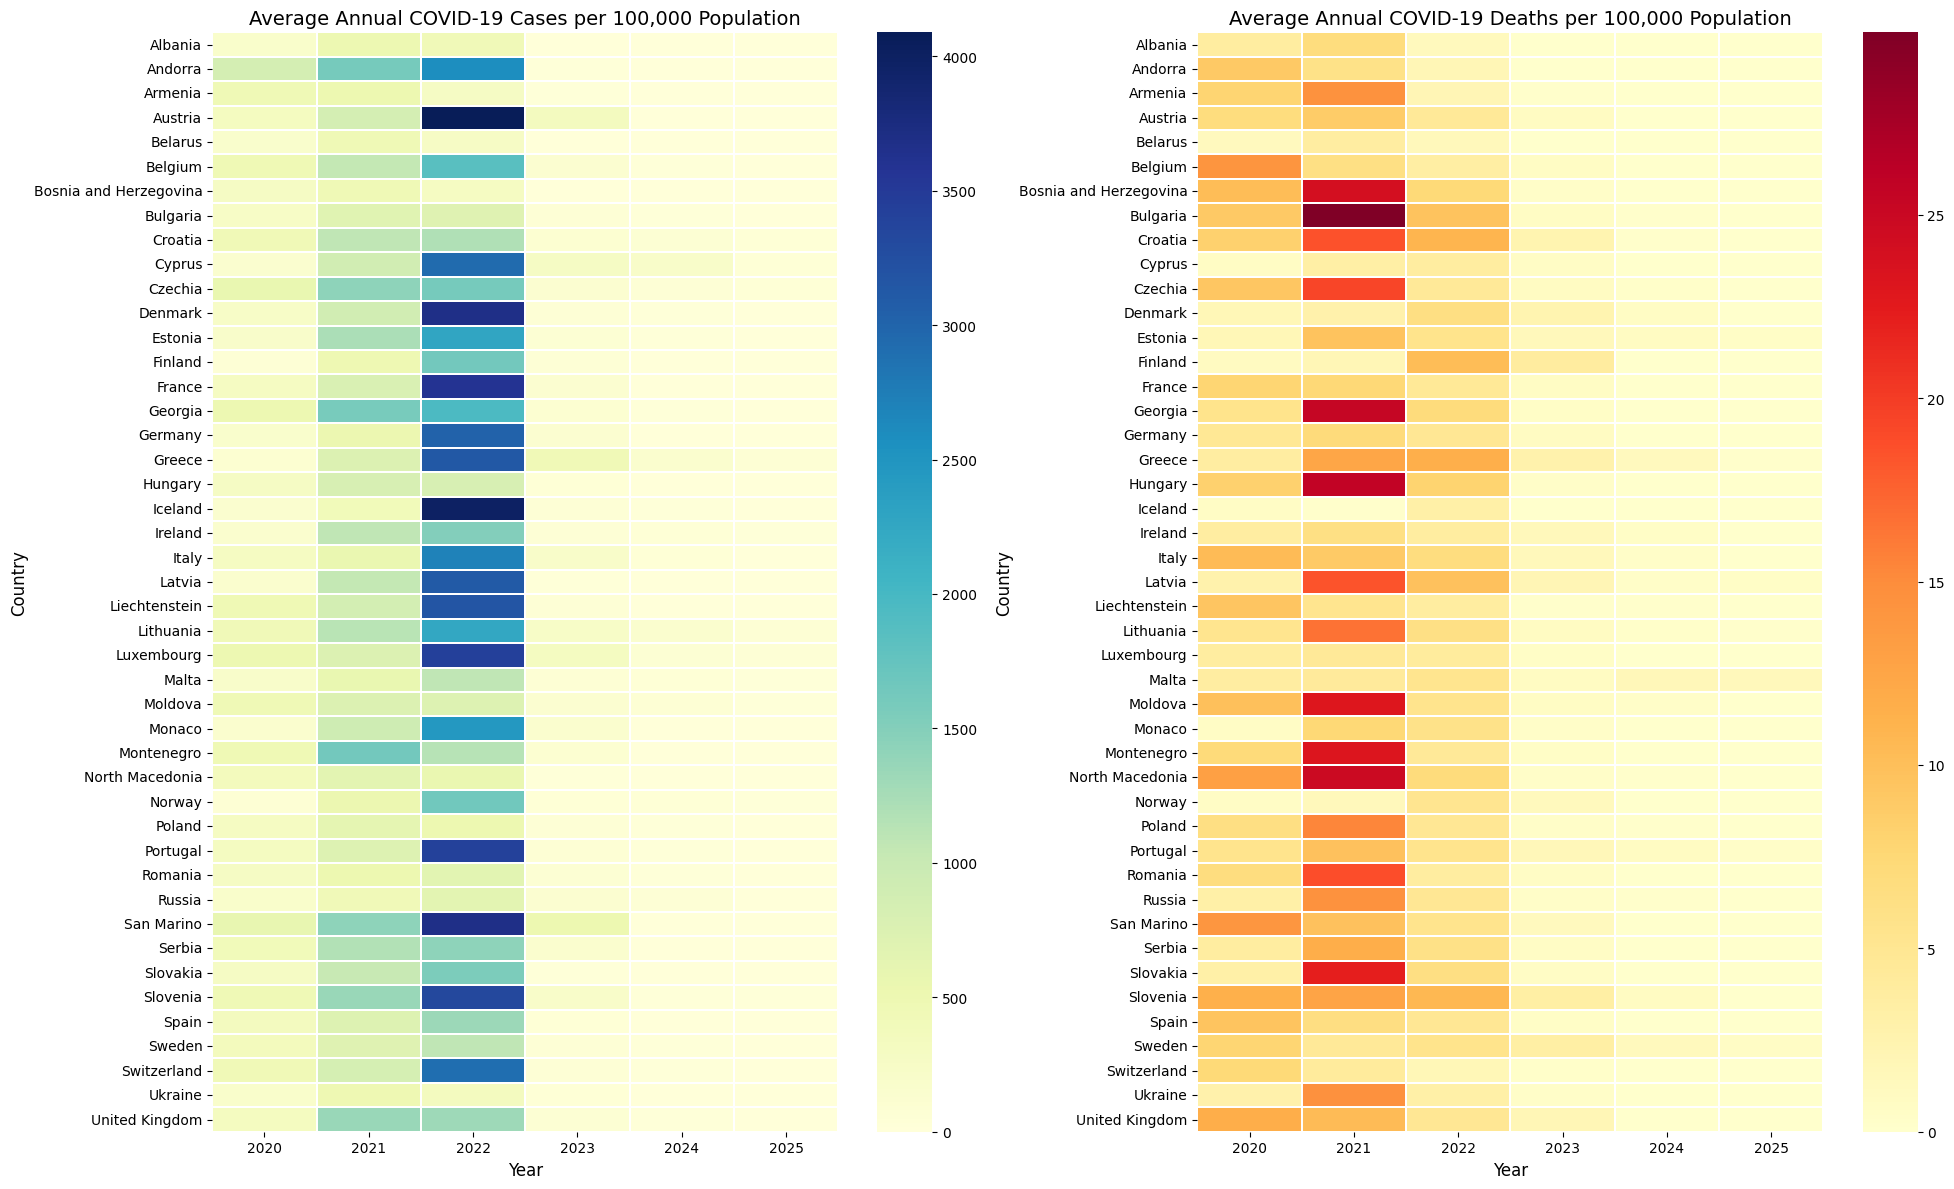

In [7]:
cases_avg = monthly_pop.groupby(["Country", "Year"])["Cases_per_100k"].mean().unstack()
deaths_avg = monthly_pop.groupby(["Country", "Year"])["Deaths_per_100k"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(20, 12))

sns.heatmap(cases_avg, cmap="YlGnBu", linewidths=0.1, ax=axes[0])
axes[0].set_title("Average Annual COVID-19 Cases per 100,000 Population", fontsize=14)
axes[0].set_xlabel("Year", fontsize=12)
axes[0].set_ylabel("Country", fontsize=12)

sns.heatmap(deaths_avg, cmap="YlOrRd", linewidths=0.1, ax=axes[1])
axes[1].set_title("Average Annual COVID-19 Deaths per 100,000 Population", fontsize=14)
axes[1].set_xlabel("Year", fontsize=12)
axes[1].set_ylabel("Country", fontsize=12)

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_1.png", dpi=600, bbox_inches="tight")
plt.show()

Mortality is highest in 2020–2021 and infection intensity peaks in 2021–2022;
from 2023 onward both indicators decline to low residual levels, with a
pronounced east–west gradient.

### Figure 2 — Correlation between COVID-19 incidence and mortality rates over time

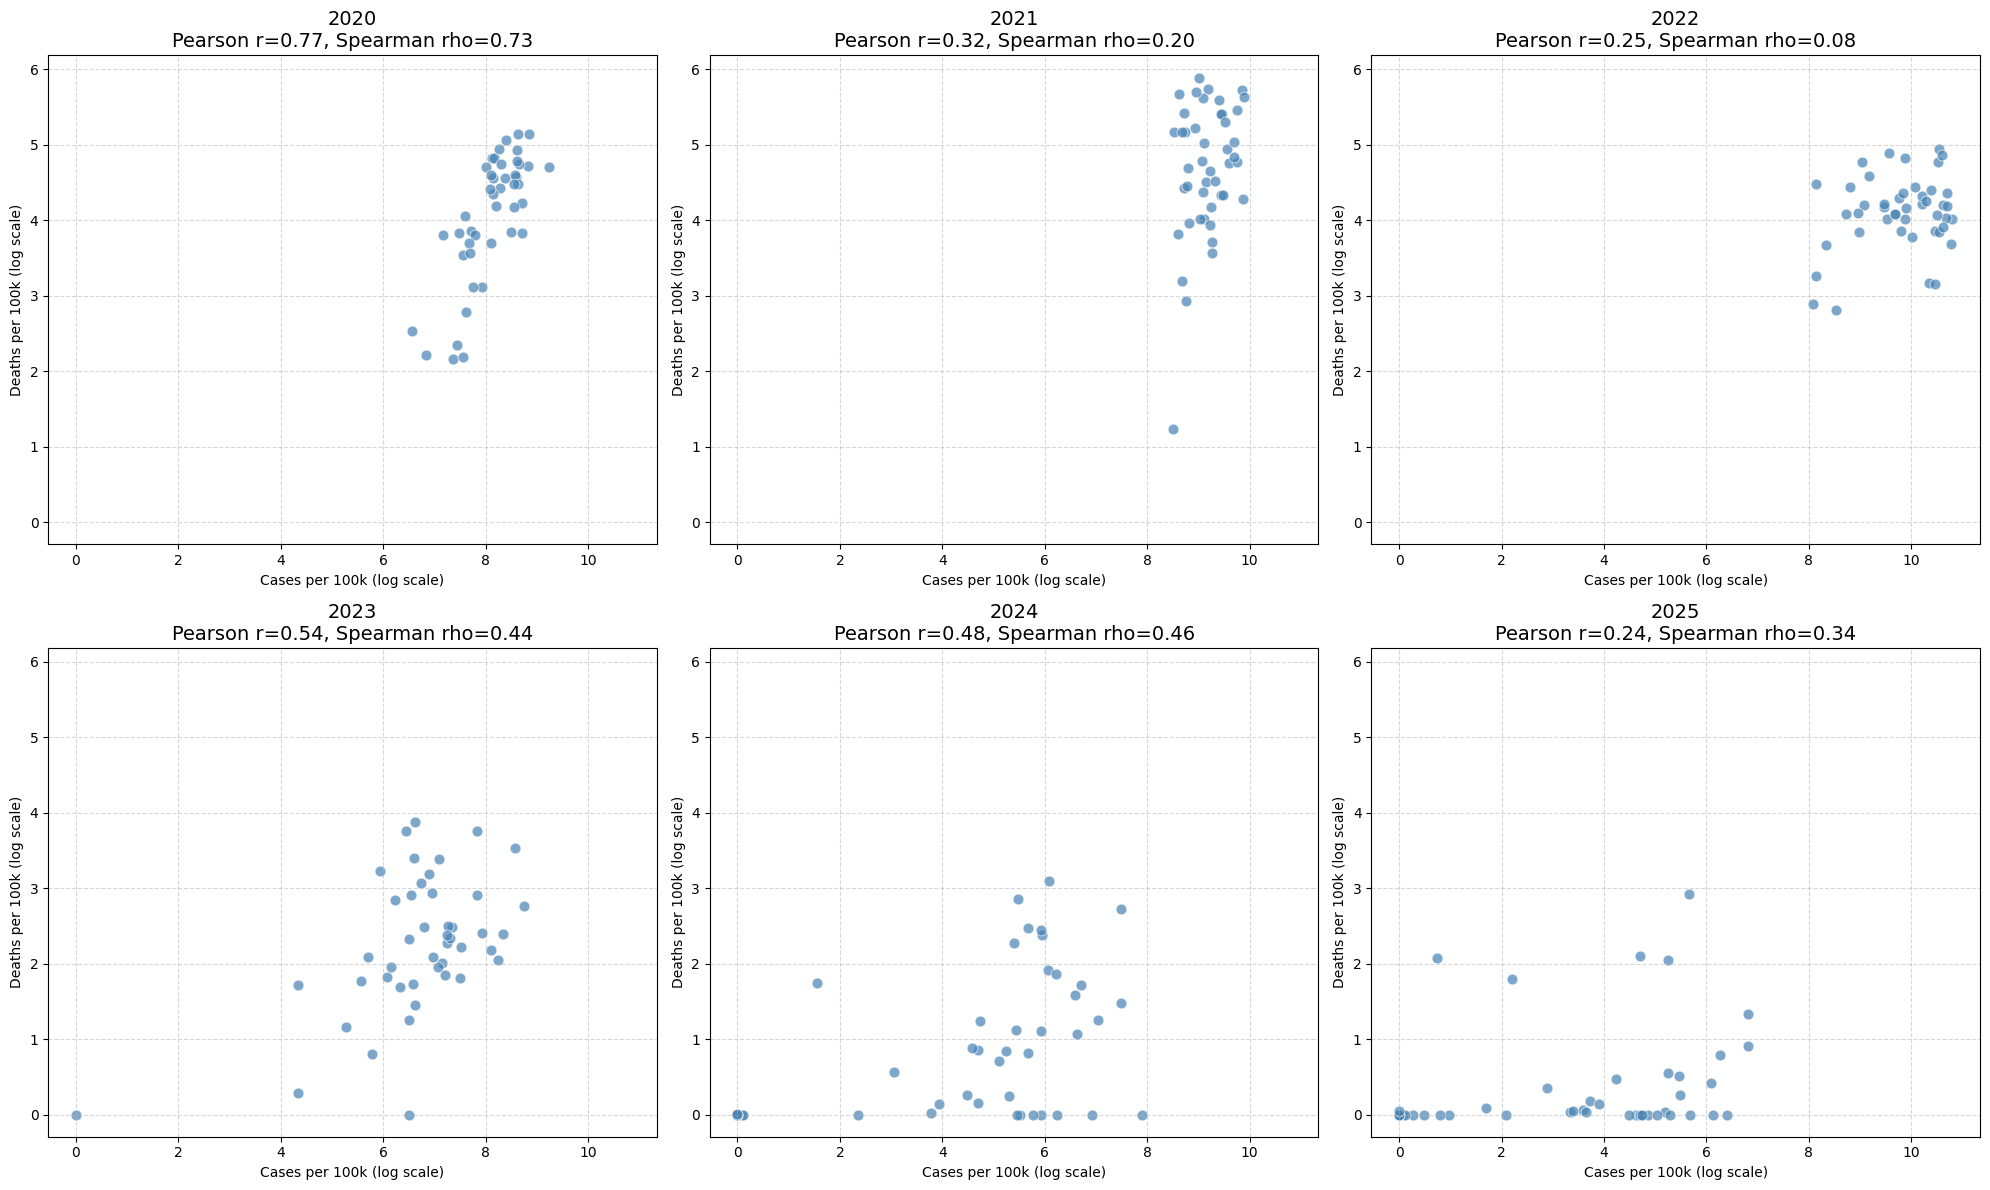

In [8]:
yearly["Cases_log"] = np.log1p(yearly["Cases_per_100k"])
yearly["Deaths_log"] = np.log1p(yearly["Deaths_per_100k"])

x_min, x_max = yearly["Cases_log"].min(), yearly["Cases_log"].max()
y_min, y_max = yearly["Deaths_log"].min(), yearly["Deaths_log"].max()
pad_x = (x_max - x_min) * 0.05
pad_y = (y_max - y_min) * 0.05
x_lim = (x_min - pad_x, x_max + pad_x)
y_lim = (y_min - pad_y, y_max + pad_y)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, yr in enumerate(YEARS):
    data = yearly[yearly["Year"] == yr].copy()
    pearson_r, _ = pearsonr(data["Cases_log"], data["Deaths_log"])
    spearman_r, _ = spearmanr(data["Cases_log"], data["Deaths_log"])

    sns.scatterplot(data=data, x="Cases_log", y="Deaths_log", ax=axes[i],
                    alpha=0.7, s=60, color="steelblue")
    axes[i].set_title(f"{yr}\nPearson r={pearson_r:.2f}, Spearman rho={spearman_r:.2f}",
                      fontsize=14)
    axes[i].set_xlabel("Cases per 100k (log scale)")
    axes[i].set_ylabel("Deaths per 100k (log scale)")
    axes[i].set_xlim(x_lim)
    axes[i].set_ylim(y_lim)
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(len(YEARS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_2.png", dpi=600, bbox_inches="tight")
plt.show()

The case–mortality association is strongest in 2020 (r ≈ 0.77) and weakens in
later years as mitigation strategies diverge.

### Figure 3 — Temporal trajectories of incidence and mortality for selected countries

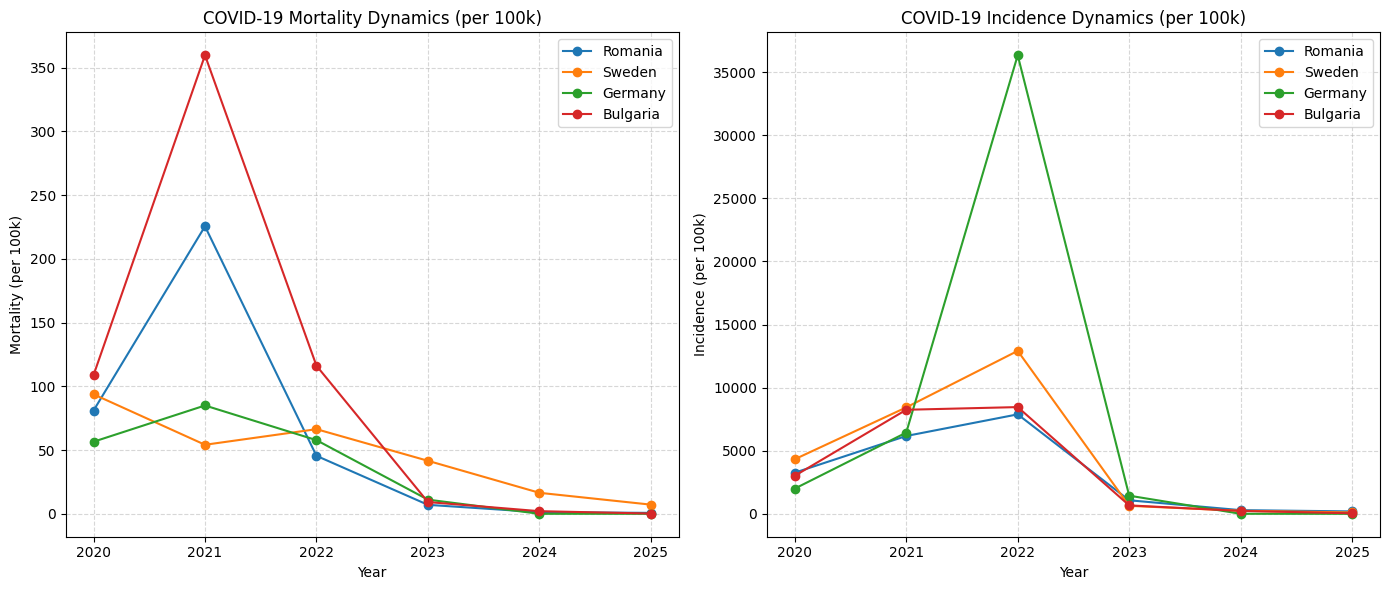

In [9]:
countries = ["Romania", "Sweden", "Germany", "Bulgaria"]
df_sel = yearly[yearly["Country"].isin(countries)]
years_sorted = sorted(df_sel["Year"].astype(int).unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for c in countries:
    d = df_sel[df_sel["Country"] == c]
    axes[0].plot(d["Year"].astype(int), d["Deaths_per_100k"], marker="o", label=c)
axes[0].set_title("COVID-19 Mortality Dynamics (per 100k)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mortality (per 100k)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()
axes[0].set_xticks(years_sorted)

for c in countries:
    d = df_sel[df_sel["Country"] == c]
    axes[1].plot(d["Year"].astype(int), d["Cases_per_100k"], marker="o", label=c)
axes[1].set_title("COVID-19 Incidence Dynamics (per 100k)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Incidence (per 100k)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()
axes[1].set_xticks(years_sorted)

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_3.png", dpi=600, bbox_inches="tight")
plt.show()

Bulgaria shows the sharpest mortality peak (2021), Germany the highest incidence
(2022), while Sweden stays at moderate incidence and low mortality throughout.

## 3. Clustering results and stability (Table 1–2, Fig. 4–9)

For each year the standardised 24-dimensional profiles are projected with PCA
(≥ 90 % variance) and clustered. Ward, k-means, GMM and spectral clustering use a
fixed `k = 6`; OPTICS determines the number of clusters from density structure.

### Table 1 — Performance comparison of clustering algorithms across 2020–2025

In [10]:
def cluster_once(X, method="kmeans", k=6, random_state=RANDOM_STATE, **kwargs):
    if method == "kmeans":
        labels = KMeans(n_clusters=k, random_state=random_state,
                        n_init=50, **kwargs).fit_predict(X)
    elif method == "ward":
        labels = AgglomerativeClustering(n_clusters=k, linkage="ward",
                                         **kwargs).fit_predict(X)
    elif method == "gmm":
        labels = GaussianMixture(n_components=k, random_state=random_state,
                                 n_init=50, reg_covar=1e-6, **kwargs).fit_predict(X)
    elif method == "spectral":
        labels = SpectralClustering(n_clusters=k, affinity="nearest_neighbors",
                                    random_state=random_state, **kwargs).fit_predict(X)
    elif method == "optics":
        labels = OPTICS(**kwargs).fit_predict(X)
    else:
        raise ValueError(f"Unknown method: {method}")

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters >= 2:
        metrics = dict(
            silhouette=silhouette_score(X, labels),
            db=davies_bouldin_score(X, labels),
            calinski=calinski_harabasz_score(X, labels),
        )
    else:
        metrics = dict(silhouette=np.nan, db=np.nan, calinski=np.nan)
    return labels, n_clusters, metrics


METHODS = {
    "kmeans": dict(k=6),
    "ward": dict(k=6),
    "gmm": dict(k=6, covariance_type="full"),
    "spectral": dict(k=6, n_neighbors=10),
    "optics": dict(min_samples=3, xi=0.05),
}

records = []
for yr in YEARS:
    X_year = pivot.xs(yr, level="Year")
    X_scaled = StandardScaler().fit_transform(X_year)
    X_pca = PCA(n_components=0.90, random_state=RANDOM_STATE).fit_transform(X_scaled)

    for m_name, m_params in METHODS.items():
        labels, k_found, metr = cluster_once(X_pca, method=m_name, **m_params)
        records.append(dict(
            Year=yr,
            Method=m_name,
            Clusters=k_found,
            Silhouette=metr["silhouette"],
            DaviesBouldin=metr["db"],
            CalinskiHarabasz=metr["calinski"],
        ))

method_order = ["ward", "gmm", "kmeans", "optics", "spectral"]
results_df = pd.DataFrame(records)
results_df["Method"] = pd.Categorical(results_df["Method"], method_order, ordered=True)
results_df = (
    results_df.set_index(["Year", "Method"])
    .sort_index()
    .round(3)
)
results_df

Clusters  Silhouette  DaviesBouldin  CalinskiHarabasz
Year Method                                                         
2020 ward             6       0.223          1.107            10.585
     gmm              6       0.179          1.382             8.804
     kmeans           6       0.219          1.101            10.613
     optics           3      -0.025          1.802             2.863
     spectral         6       0.096          1.562             6.234
2021 ward             6       0.230          1.142            12.169
     gmm              6       0.216          1.365             9.990
     kmeans           6       0.228          1.149            11.954
     optics           5      -0.036          1.902             2.541
     spectral         6       0.191          1.385             9.058
2022 ward             6       0.206          1.168            11.932
     gmm              6       0.142          1.518             9.555
     kmeans           6       0.219          1.128            12.482
     optics           2       0.009          1.944             4.880
     spectral         6       0.218          1.278            11.230
2023 ward             6       0.338          0.834            16.399
     gmm              6       0.260          1.300            14.417
     kmeans           6       0.301          1.009            16.799
     optics           4      -0.093          2.092             2.424
     spectral         6       0.092          1.317             9.913
2024 ward             6       0.472          1.095            18.578
     gmm              6       0.480          1.056            17.364
     kmeans           6       0.502          1.007            21.368
     optics           2       0.146          1.496             6.238
     spectral         6       0.165          1.425            10.044
2025 ward             6       0.610          0.569            66.256
     gmm              6       0.471          0.698            58.995
     kmeans           6       0.610          0.569            66.256
     optics           4       0.242          1.678             3.872
     spectral         6       0.280          1.508            12.072

OPTICS labels noise as `-1`; its internal indices are descriptive diagnostics and
are not directly comparable with the fixed-`k` methods. Ward and k-means give the
strongest solutions in every year and converge in 2025
(Silhouette = 0.610, Davies–Bouldin = 0.569, Calinski–Harabasz = 66.256).

This cell reproduces Table 1 of the article for all five methods; Table 1 as
printed in the manuscript omits the 2025 `spectral` row for brevity.

### Table 2 — Best-performing clustering configuration by year and metric

In [11]:
def best_methods(series, mode):
    # all methods tied for the optimum (values rounded to 3 decimals)
    s = series.round(3)
    target = s.min() if mode == "min" else s.max()
    return ", ".join(sorted(s.index[s == target].get_level_values("Method")))


best_rows = []
for yr in YEARS:
    block = results_df.loc[yr]
    best_rows.append(dict(
        Year=yr,
        Best_by_Silhouette=best_methods(block["Silhouette"], "max"),
        Best_by_DaviesBouldin=best_methods(block["DaviesBouldin"], "min"),
        Best_by_CalinskiHarabasz=best_methods(block["CalinskiHarabasz"], "max"),
    ))

best_configs = pd.DataFrame(best_rows).set_index("Year")
best_configs

,Best_by_Silhouette,Best_by_DaviesBouldin,Best_by_CalinskiHarabasz
Year,,,
2020,ward,kmeans,kmeans
2021,ward,ward,ward
2022,kmeans,kmeans,kmeans
2023,ward,ward,kmeans
2024,kmeans,kmeans,kmeans
2025,"kmeans, ward","kmeans, ward","kmeans, ward"


### Figure 4 — PCA projections of Ward and k-means under year-specific silhouette-optimised k

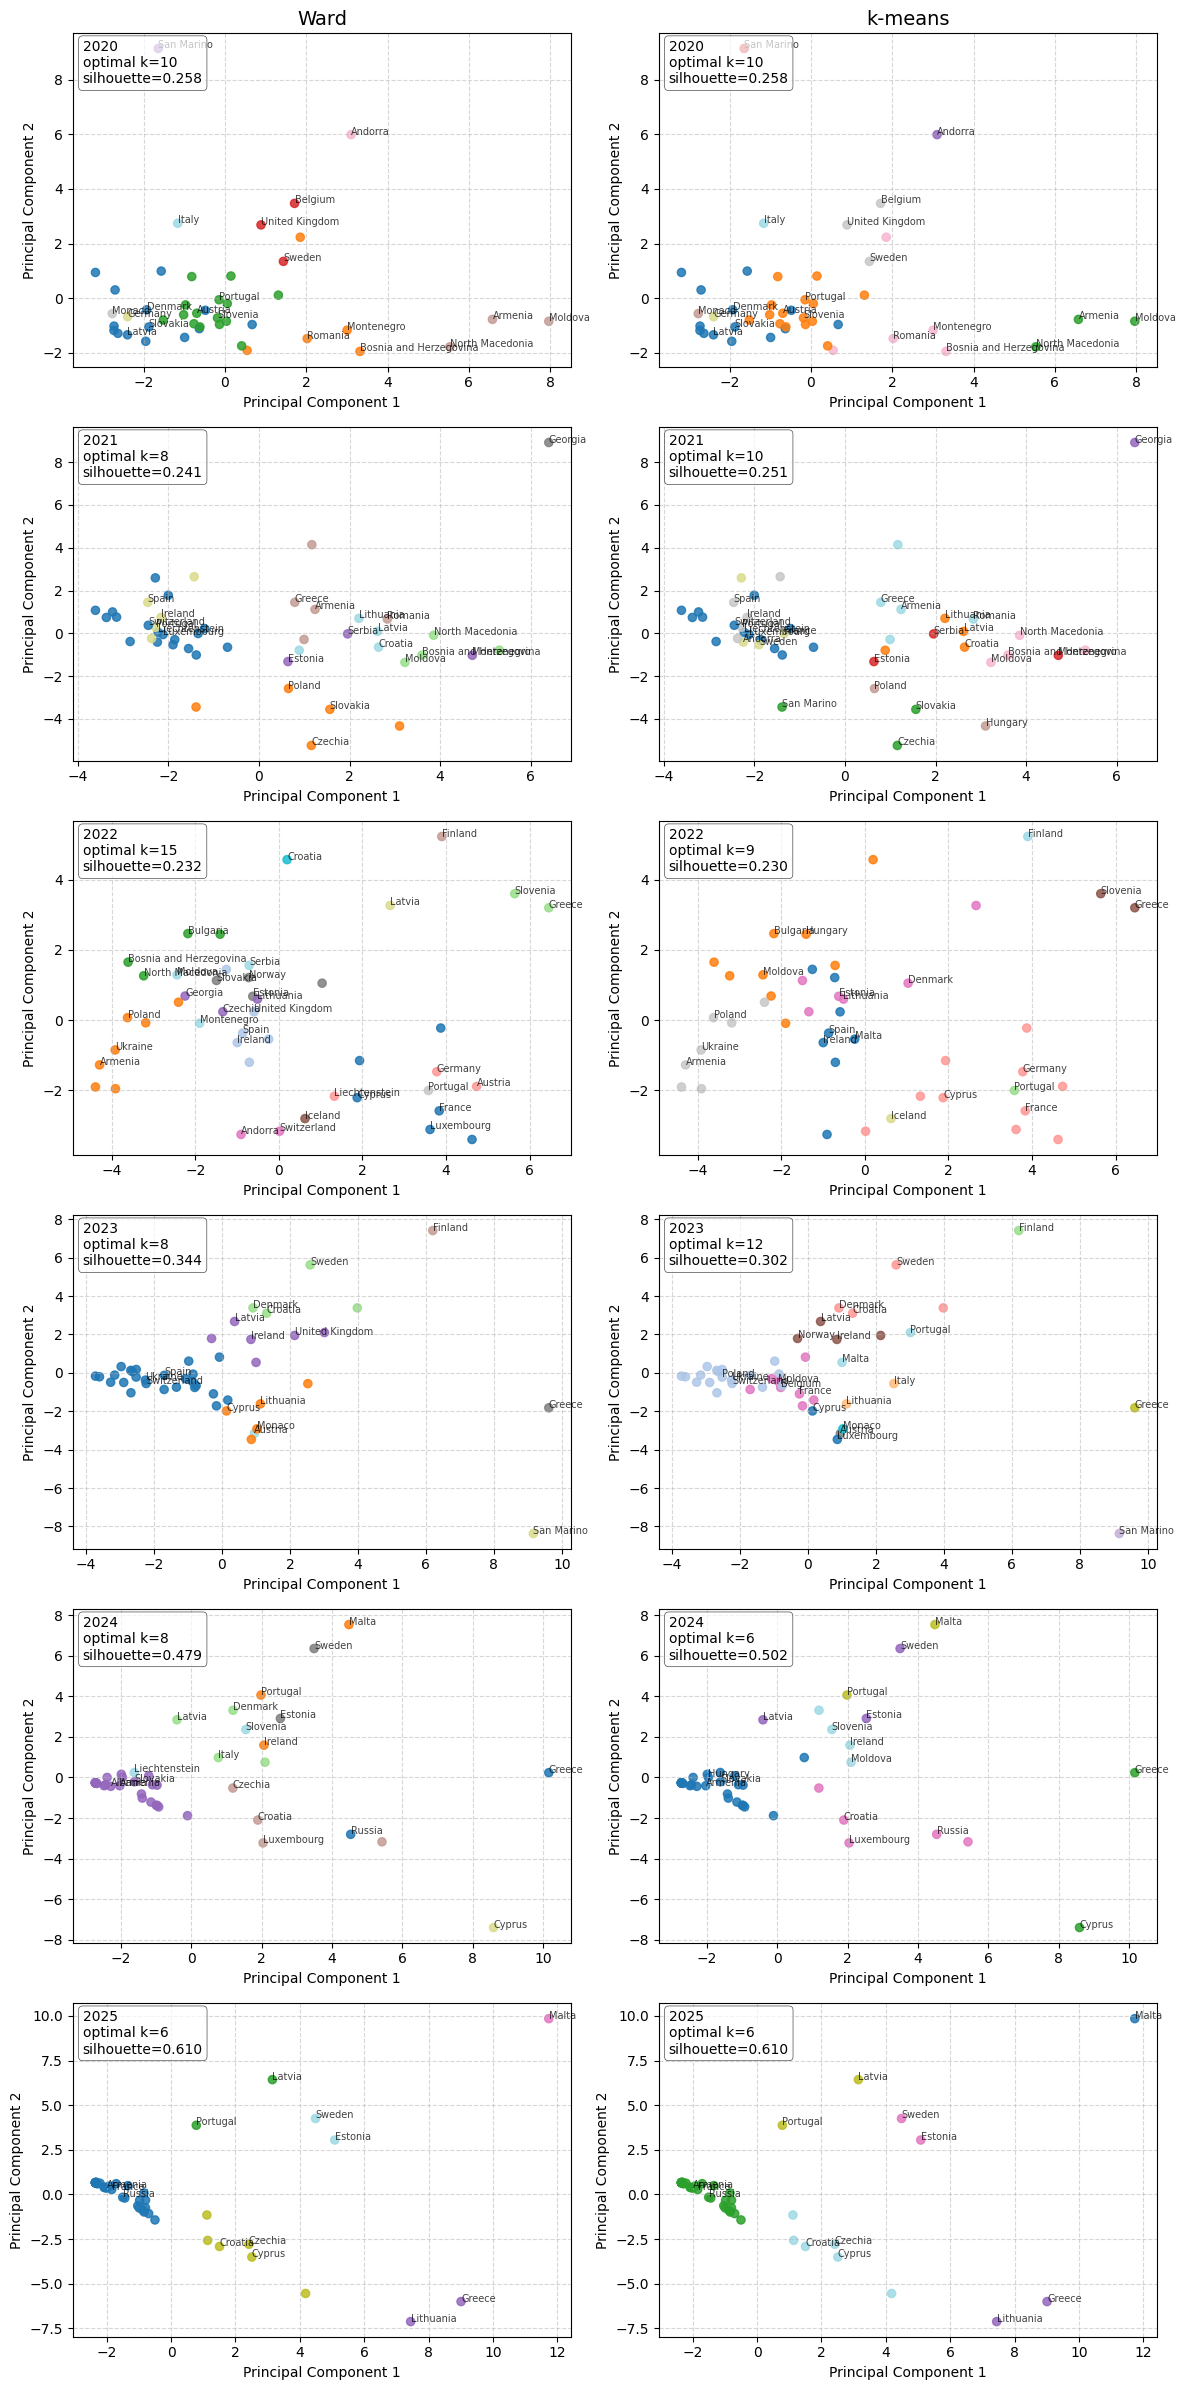

In [12]:
def annotate_representatives(ax, df_plot, label_col, n_labels=3):
    for cluster_id in sorted(df_plot[label_col].unique()):
        cluster_df = df_plot[df_plot[label_col] == cluster_id]
        if cluster_df.empty:
            continue
        centroid = cluster_df[["PC1", "PC2"]].mean().values
        distances = np.linalg.norm(cluster_df[["PC1", "PC2"]].values - centroid, axis=1)
        n_take = min(n_labels, len(cluster_df))
        reps = cluster_df.iloc[np.argsort(distances)[:n_take]]
        for _, r in reps.iterrows():
            ax.text(r.PC1, r.PC2, r.Country, fontsize=7, alpha=0.75)


k_grid = range(6, 17)
n_init_kmeans = 50
labels_per_cluster = 3

fig, axes = plt.subplots(nrows=len(YEARS), ncols=2, figsize=(12, 4 * len(YEARS)))
if len(YEARS) == 1:
    axes = np.array([axes])

axes[0, 0].set_title("Ward", fontsize=14)
axes[0, 1].set_title("k-means", fontsize=14)

for i, year in enumerate(YEARS):
    pivot_year = (pivot.reset_index()
                  .loc[lambda d: d["Year"] == year]
                  .set_index(["Country", "Year"]))
    countries = pivot_year.index.get_level_values("Country").to_numpy()

    X = StandardScaler().fit_transform(pivot_year.values)
    comp = PCA(n_components=0.90, random_state=RANDOM_STATE).fit_transform(X)

    best_k_ward, best_sil_ward, best_labels_ward = None, -np.inf, None
    for k in k_grid:
        labels_tmp = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(comp)
        n_clusters = len(np.unique(labels_tmp))
        if n_clusters < 2 or n_clusters >= len(labels_tmp):
            continue
        sil = silhouette_score(comp, labels_tmp)
        if sil > best_sil_ward:
            best_k_ward, best_sil_ward, best_labels_ward = k, sil, labels_tmp
    if best_labels_ward is None:
        best_k_ward = min(k_grid)
        best_labels_ward = AgglomerativeClustering(n_clusters=best_k_ward, linkage="ward").fit_predict(comp)
        best_sil_ward = silhouette_score(comp, best_labels_ward)

    best_k_km, best_sil_km, best_labels_km = None, -np.inf, None
    for k in k_grid:
        labels_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE,
                            n_init=n_init_kmeans).fit_predict(comp)
        n_clusters = len(np.unique(labels_tmp))
        if n_clusters < 2 or n_clusters >= len(labels_tmp):
            continue
        sil = silhouette_score(comp, labels_tmp)
        if sil > best_sil_km:
            best_k_km, best_sil_km, best_labels_km = k, sil, labels_tmp
    if best_labels_km is None:
        best_k_km = min(k_grid)
        best_labels_km = KMeans(n_clusters=best_k_km, random_state=RANDOM_STATE,
                                n_init=n_init_kmeans).fit_predict(comp)
        best_sil_km = silhouette_score(comp, best_labels_km)

    df_plot = pd.DataFrame({
        "Country": countries,
        "PC1": comp[:, 0],
        "PC2": comp[:, 1],
        "Ward": best_labels_ward,
        "KMeans": best_labels_km,
    })

    ax1 = axes[i, 0]
    ax1.scatter(df_plot["PC1"], df_plot["PC2"], c=df_plot["Ward"], cmap="tab20", s=35, alpha=0.85)
    annotate_representatives(ax1, df_plot, "Ward", n_labels=labels_per_cluster)
    ax1.set_xlabel("Principal Component 1")
    ax1.set_ylabel("Principal Component 2")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.text(0.02, 0.98, f"{year}\noptimal k={best_k_ward}\nsilhouette={best_sil_ward:.3f}",
             transform=ax1.transAxes, va="top", ha="left", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, linewidth=0.5))

    ax2 = axes[i, 1]
    ax2.scatter(df_plot["PC1"], df_plot["PC2"], c=df_plot["KMeans"], cmap="tab20", s=35, alpha=0.85)
    annotate_representatives(ax2, df_plot, "KMeans", n_labels=labels_per_cluster)
    ax2.set_xlabel("Principal Component 1")
    ax2.set_ylabel("Principal Component 2")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.text(0.02, 0.98, f"{year}\noptimal k={best_k_km}\nsilhouette={best_sil_km:.3f}",
             transform=ax2.transAxes, va="top", ha="left", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, linewidth=0.5))

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_4_Ward_vs_KMeans_optimal_k_annotated.png", dpi=300, bbox_inches="tight")
plt.show()

Cluster separability improves over time: substantial overlap in 2020–2022,
clearer boundaries from 2023, and near-identical Ward / k-means partitions in
2025.

### Figure 5 — Ward and k-means clustering with identified outliers

Countries are flagged as atypical when they belong to a cluster with fewer than
three members or fall in the upper 5th percentile of distance to their cluster
centroid. The `comparison` dictionary built here is reused by Fig. 6 and Fig. 7.

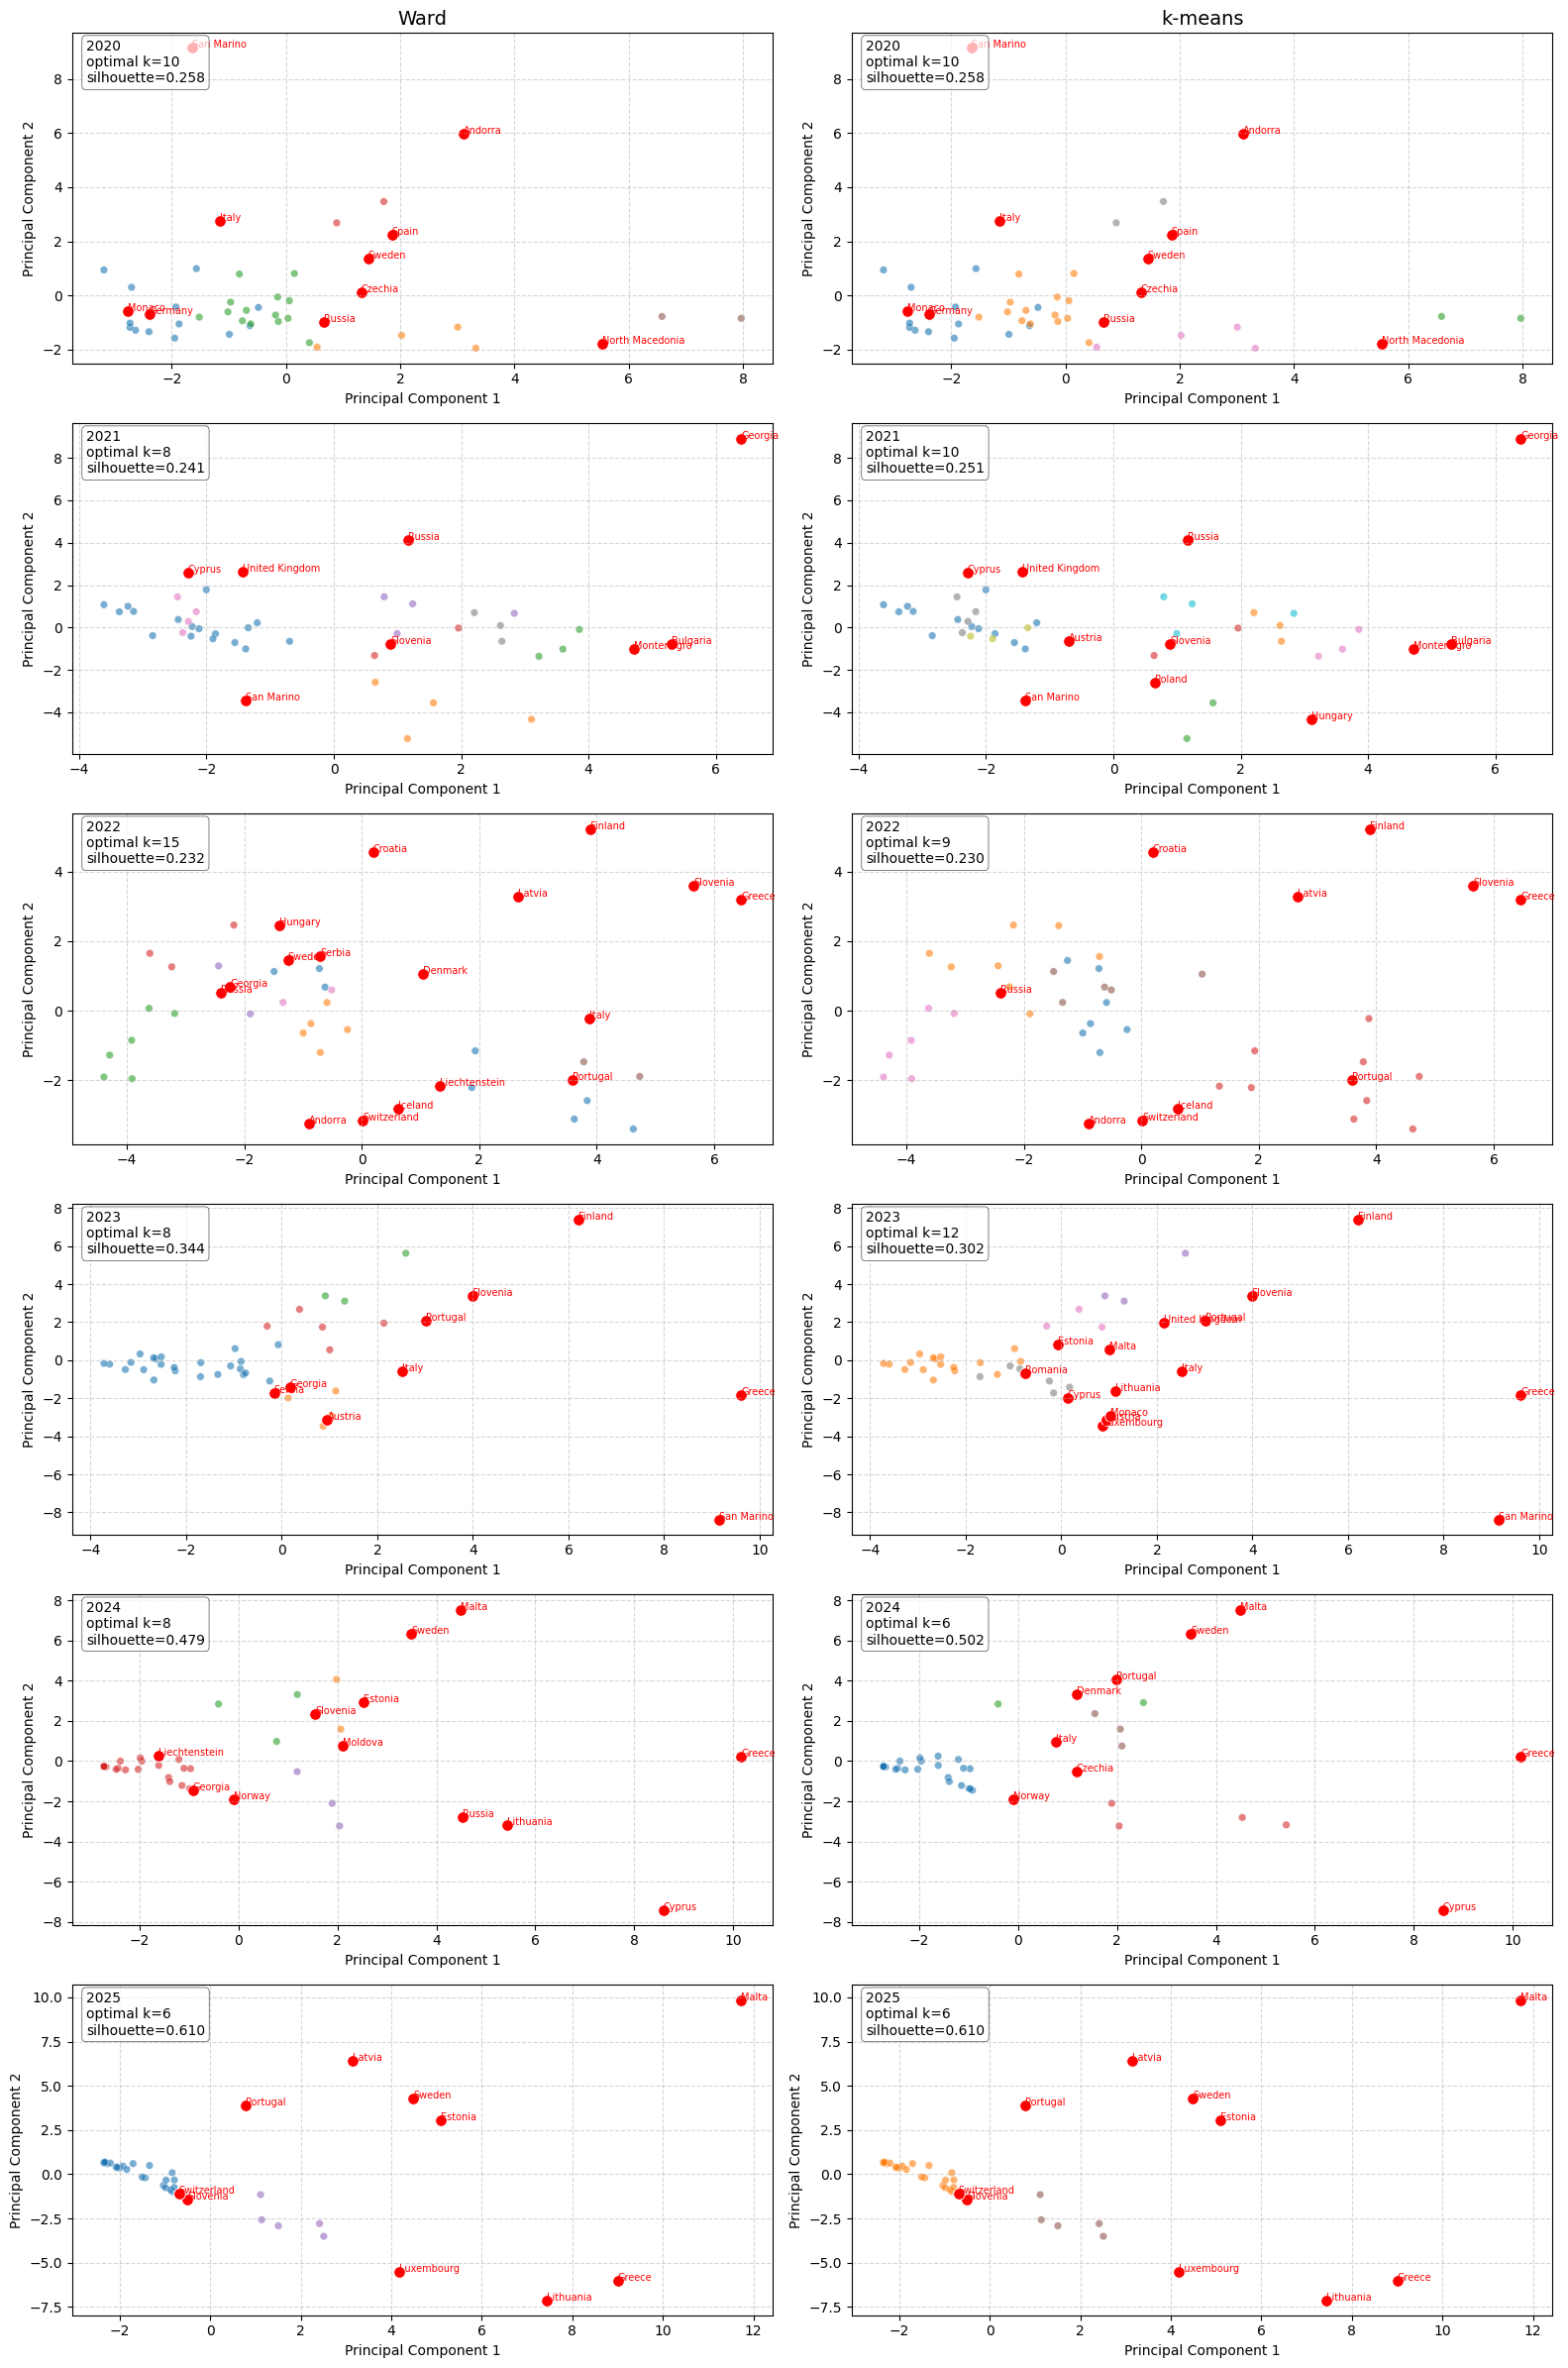

,Best_k_KMeans,Best_k_Ward,Sil_KMeans,Sil_Ward,KMeans_Outliers,Ward_Outliers,Common
2020,10,10,0.258,0.258,"[Czechia, Russia, Spain, North Macedonia, Swed...","[Czechia, Russia, Spain, North Macedonia, Swed...","[North Macedonia, San Marino, Andorra, Czechia..."
2021,10,8,0.251,0.241,"[Austria, Russia, United Kingdom, Cyprus, Slov...","[Cyprus, Russia, United Kingdom, San Marino, S...","[United Kingdom, Cyprus, San Marino, Slovenia,..."
2022,9,15,0.23,0.232,"[Switzerland, Croatia, Andorra, Russia, Latvia...","[Russia, Italy, Sweden, Hungary, Denmark, Geor...","[Greece, Andorra, Latvia, Finland, Slovenia, I..."
2023,12,8,0.302,0.344,"[Romania, Estonia, Slovenia, United Kingdom, M...","[Georgia, Serbia, Portugal, Italy, Slovenia, A...","[San Marino, Greece, Finland, Slovenia, Italy,..."
2024,6,8,0.502,0.479,"[Italy, Norway, Czechia, Denmark, Sweden, Cypr...","[Georgia, Norway, Lithuania, Moldova, Malta, G...","[Cyprus, Greece, Norway, Sweden, Malta]"
2025,6,6,0.61,0.61,"[Slovenia, Switzerland, Luxembourg, Estonia, S...","[Slovenia, Switzerland, Luxembourg, Estonia, S...","[Luxembourg, Estonia, Greece, Latvia, Slovenia..."


In [13]:
k_grid = range(6, 17)
n_init_kmeans = 50
comparison = {}

fig, axes = plt.subplots(nrows=len(YEARS), ncols=2, figsize=(16, 4 * len(YEARS)))
if len(YEARS) == 1:
    axes = np.array([axes])

axes[0, 0].set_title("Ward", fontsize=14)
axes[0, 1].set_title("k-means", fontsize=14)

for i, year in enumerate(YEARS):
    pivot_year = (pivot.reset_index()
                  .loc[lambda d: d["Year"] == year]
                  .set_index(["Country", "Year"]))
    X_year = StandardScaler().fit_transform(pivot_year.values)
    X_pca = PCA(n_components=0.90, random_state=RANDOM_STATE).fit_transform(X_year)
    comp2 = X_pca[:, :2]

    best_k_km, best_score_km = None, -np.inf
    for k in k_grid:
        labels_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE,
                            n_init=n_init_kmeans).fit_predict(X_pca)
        if len(np.unique(labels_tmp)) < 2:
            continue
        sil = silhouette_score(X_pca, labels_tmp)
        if sil > best_score_km:
            best_k_km, best_score_km = k, sil

    kmeans = KMeans(n_clusters=best_k_km, random_state=RANDOM_STATE, n_init=n_init_kmeans)
    clusters_km = kmeans.fit_predict(X_pca)
    df_kmeans = pd.DataFrame({
        "Country": pivot_year.index.get_level_values("Country"),
        "PC1": comp2[:, 0], "PC2": comp2[:, 1], "Cluster": clusters_km,
    })
    centers_km = kmeans.cluster_centers_[:, :2]
    distances_km = cdist(X_pca[:, :2], centers_km)
    df_kmeans["Dist"] = [distances_km[ii, c] for ii, c in enumerate(clusters_km)]

    outliers_km = []
    for clust, size in df_kmeans["Cluster"].value_counts().items():
        subset = df_kmeans[df_kmeans["Cluster"] == clust]
        if size < 3:
            outliers_km.append(subset)
        else:
            thr = np.percentile(subset["Dist"], 95)
            outliers_km.append(subset[subset["Dist"] > thr])
    outliers_km = pd.concat(outliers_km) if outliers_km else df_kmeans.iloc[0:0]

    best_k_w, best_score_w = None, -np.inf
    for k in k_grid:
        labels_tmp = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_pca)
        if len(np.unique(labels_tmp)) < 2:
            continue
        sil = silhouette_score(X_pca, labels_tmp)
        if sil > best_score_w:
            best_k_w, best_score_w = k, sil

    clusters_w = AgglomerativeClustering(n_clusters=best_k_w, linkage="ward").fit_predict(X_pca)
    df_ward = pd.DataFrame({
        "Country": pivot_year.index.get_level_values("Country"),
        "PC1": comp2[:, 0], "PC2": comp2[:, 1], "Cluster": clusters_w,
    })
    centers_w = df_ward.groupby("Cluster")[["PC1", "PC2"]].mean().values
    distances_w = cdist(df_ward[["PC1", "PC2"]], centers_w)
    df_ward["Dist"] = [distances_w[ii, c] for ii, c in enumerate(clusters_w)]

    outliers_w = []
    for clust, size in df_ward["Cluster"].value_counts().items():
        subset = df_ward[df_ward["Cluster"] == clust]
        if size < 3:
            outliers_w.append(subset)
        else:
            thr = np.percentile(subset["Dist"], 95)
            outliers_w.append(subset[subset["Dist"] > thr])
    outliers_w = pd.concat(outliers_w) if outliers_w else df_ward.iloc[0:0]

    comparison[year] = {
        "Best_k_KMeans": best_k_km,
        "Best_k_Ward": best_k_w,
        "Sil_KMeans": round(best_score_km, 3),
        "Sil_Ward": round(best_score_w, 3),
        "KMeans_Outliers": list(outliers_km["Country"]),
        "Ward_Outliers": list(outliers_w["Country"]),
        "Common": list(set(outliers_km["Country"]).intersection(outliers_w["Country"])),
    }

    ax1 = axes[i, 1]
    sns.scatterplot(data=df_kmeans, x="PC1", y="PC2", hue="Cluster", palette="tab10",
                    s=30, alpha=0.6, ax=ax1, legend=False)
    sns.scatterplot(data=outliers_km, x="PC1", y="PC2", color="red", s=70, ax=ax1)
    for _, row in outliers_km.iterrows():
        ax1.text(row["PC1"], row["PC2"], row["Country"], fontsize=7, color="red")
    ax1.set_xlabel("Principal Component 1")
    ax1.set_ylabel("Principal Component 2")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.text(0.02, 0.98, f"{year}\noptimal k={best_k_km}\nsilhouette={best_score_km:.3f}",
             transform=ax1.transAxes, va="top", ha="left", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, linewidth=0.5))

    ax2 = axes[i, 0]
    palette_w = sns.color_palette("tab10", best_k_w)
    sns.scatterplot(data=df_ward, x="PC1", y="PC2", hue="Cluster", palette=palette_w,
                    s=30, alpha=0.6, ax=ax2, legend=False)
    sns.scatterplot(data=outliers_w, x="PC1", y="PC2", color="red", s=70, ax=ax2)
    for _, row in outliers_w.iterrows():
        ax2.text(row["PC1"], row["PC2"], row["Country"], fontsize=7, color="red")
    ax2.set_xlabel("Principal Component 1")
    ax2.set_ylabel("Principal Component 2")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.text(0.02, 0.98, f"{year}\noptimal k={best_k_w}\nsilhouette={best_score_w:.3f}",
             transform=ax2.transAxes, va="top", ha="left", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, linewidth=0.5))

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_5_KMeans_Ward_Outliers.png", dpi=600, bbox_inches="tight")
plt.show()

pd.DataFrame(comparison).T

Ward yields more compact partitions than k-means; a small set of countries
(San Marino, Andorra, Iceland) recurs among the outliers, while large countries
are rarely flagged.

### Figure 6 — Overlap of outlier countries detected by both algorithms

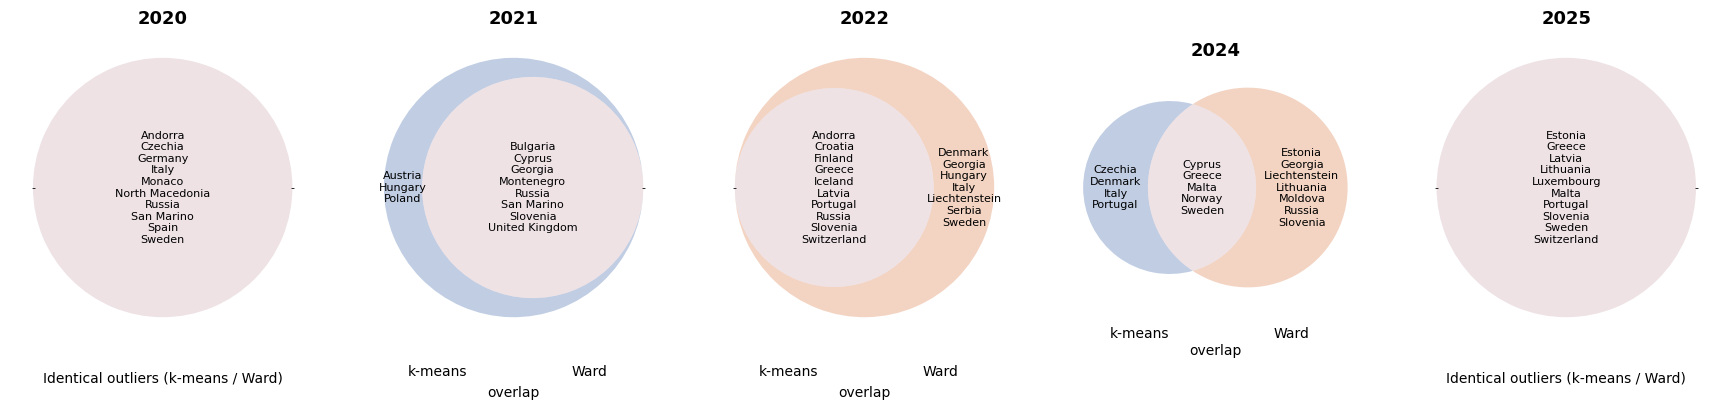

In [14]:
selected_years = [2020, 2021, 2022, 2024, 2025]

FONT_COUNTRIES = 8
FONT_METHODS = 10
TITLE_FONT = 13


def join_sorted(s):
    return "\n".join(sorted(s)) if len(s) else "-"


fig, axes = plt.subplots(1, len(selected_years), figsize=(18, 5))
plt.subplots_adjust(wspace=0.7)

for i, year in enumerate(selected_years):
    vals = comparison[year]
    km = set(vals["KMeans_Outliers"])
    wd = set(vals["Ward_Outliers"])
    common = set(vals["Common"])
    km_only = km - common
    wd_only = wd - common

    ax = axes[i]
    v = venn2(subsets=(len(km_only), len(wd_only), len(common)),
              set_labels=(None, None),
              set_colors=("#4C72B0", "#DD8452"), alpha=0.35, ax=ax)
    ax.set_title(f"{year}", fontsize=TITLE_FONT, fontweight="bold", pad=8)

    for sid, content in (("10", km_only), ("01", wd_only), ("11", common)):
        lbl = v.get_label_by_id(sid)
        if lbl:
            lbl.set_text(join_sorted(content))
            lbl.set_fontsize(FONT_COUNTRIES)
            lbl.set_ha("center")
            lbl.set_va("center")

    if km == wd:
        ax.text(0.5, -0.10, "Identical outliers (k-means / Ward)",
                transform=ax.transAxes, ha="center", va="top", fontsize=FONT_METHODS)
    else:
        ax.text(0.25, -0.08, "k-means", transform=ax.transAxes,
                ha="center", va="top", fontsize=FONT_METHODS)
        ax.text(0.75, -0.08, "Ward", transform=ax.transAxes,
                ha="center", va="top", fontsize=FONT_METHODS)
        ax.text(0.5, -0.15, "overlap", transform=ax.transAxes,
                ha="center", va="top", fontsize=FONT_METHODS)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_6_KMeans_Ward_Outlier_Overlap.png", dpi=600, bbox_inches="tight")
plt.show()

Outlier sets are identical for both methods in 2020, only partially overlap in
2021–2024, and converge again in 2025.

### Figure 7 — Temporal stability of cluster assignments (ARI and NMI)

ARI and NMI are computed between consecutive yearly partitions at fixed `k = 6`
in the year-specific PCA spaces.

,Period,ARI_Ward,NMI_Ward,ARI_KMeans,NMI_KMeans,Common
0,2020-2021,0.024169,0.222799,0.073196,0.287130,"United Kingdom, Cyprus, San Marino, Slovenia, ..."
1,2021-2022,0.106121,0.316632,0.144712,0.345760,"Greece, Andorra, Latvia, Finland, Slovenia, Ic..."
2,2022-2023,0.151554,0.350799,0.158871,0.376742,"San Marino, Greece, Finland, Slovenia, Italy, ..."
3,2023-2024,0.309496,0.281880,0.211075,0.310567,"Cyprus, Greece, Norway, Sweden, Malta"
4,2024-2025,0.569529,0.573103,0.656357,0.592196,"Luxembourg, Estonia, Greece, Latvia, Slovenia,..."


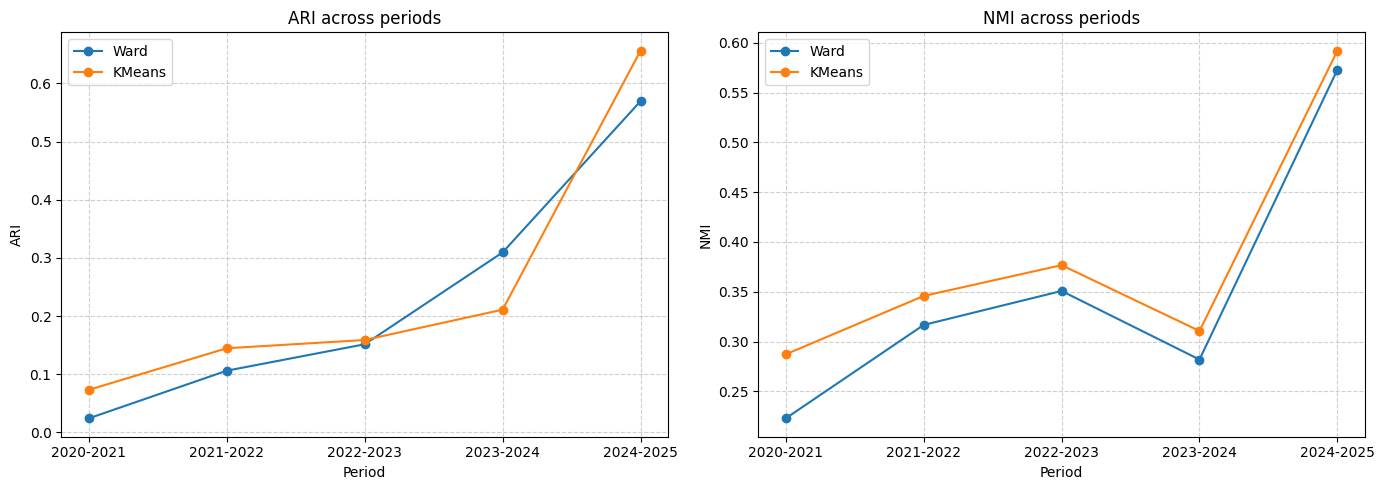

In [15]:
labels_dict = {"Ward": {}, "KMeans": {}}
for year in YEARS:
    pivot_year = (pivot.reset_index()
                  .loc[lambda d: d["Year"] == year]
                  .set_index(["Country", "Year"]))
    X_year = StandardScaler().fit_transform(pivot_year.values)
    X_pca = PCA(n_components=0.9, random_state=RANDOM_STATE).fit_transform(X_year)
    labels_dict["Ward"][year] = AgglomerativeClustering(n_clusters=6, linkage="ward").fit_predict(X_pca)
    labels_dict["KMeans"][year] = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=50).fit_predict(X_pca)

records = []
for y_prev, y_next in zip(YEARS[:-1], YEARS[1:]):
    record = {"Period": f"{y_prev}-{y_next}"}
    for method in ["Ward", "KMeans"]:
        lp, ln = labels_dict[method][y_prev], labels_dict[method][y_next]
        record[f"ARI_{method}"] = adjusted_rand_score(lp, ln)
        record[f"NMI_{method}"] = normalized_mutual_info_score(lp, ln)
    record["Common"] = ", ".join(comparison[y_next]["Common"]) if y_next in comparison else ""
    records.append(record)

metrics_df = pd.DataFrame(records)
display(metrics_df)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(metrics_df["Period"], metrics_df["ARI_Ward"], marker="o", label="Ward")
ax[0].plot(metrics_df["Period"], metrics_df["ARI_KMeans"], marker="o", label="KMeans")
ax[0].set_title("ARI across periods")
ax[0].set_ylabel("ARI")
ax[0].set_xlabel("Period")
ax[0].legend()
ax[0].grid(True, linestyle="--", alpha=0.6)

ax[1].plot(metrics_df["Period"], metrics_df["NMI_Ward"], marker="o", label="Ward")
ax[1].plot(metrics_df["Period"], metrics_df["NMI_KMeans"], marker="o", label="KMeans")
ax[1].set_title("NMI across periods")
ax[1].set_ylabel("NMI")
ax[1].set_xlabel("Period")
ax[1].legend()
ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_7_Clustering_Stability.png", dpi=300, bbox_inches="tight")
plt.show()

Both indices rise toward the mid-period comparisons and reach their maximum for
2024–2025, indicating the greatest preservation of country groupings between the
final years.

### Figure 8 — Silhouette analysis for Ward and k-means (2020–2025, k = 6–16)

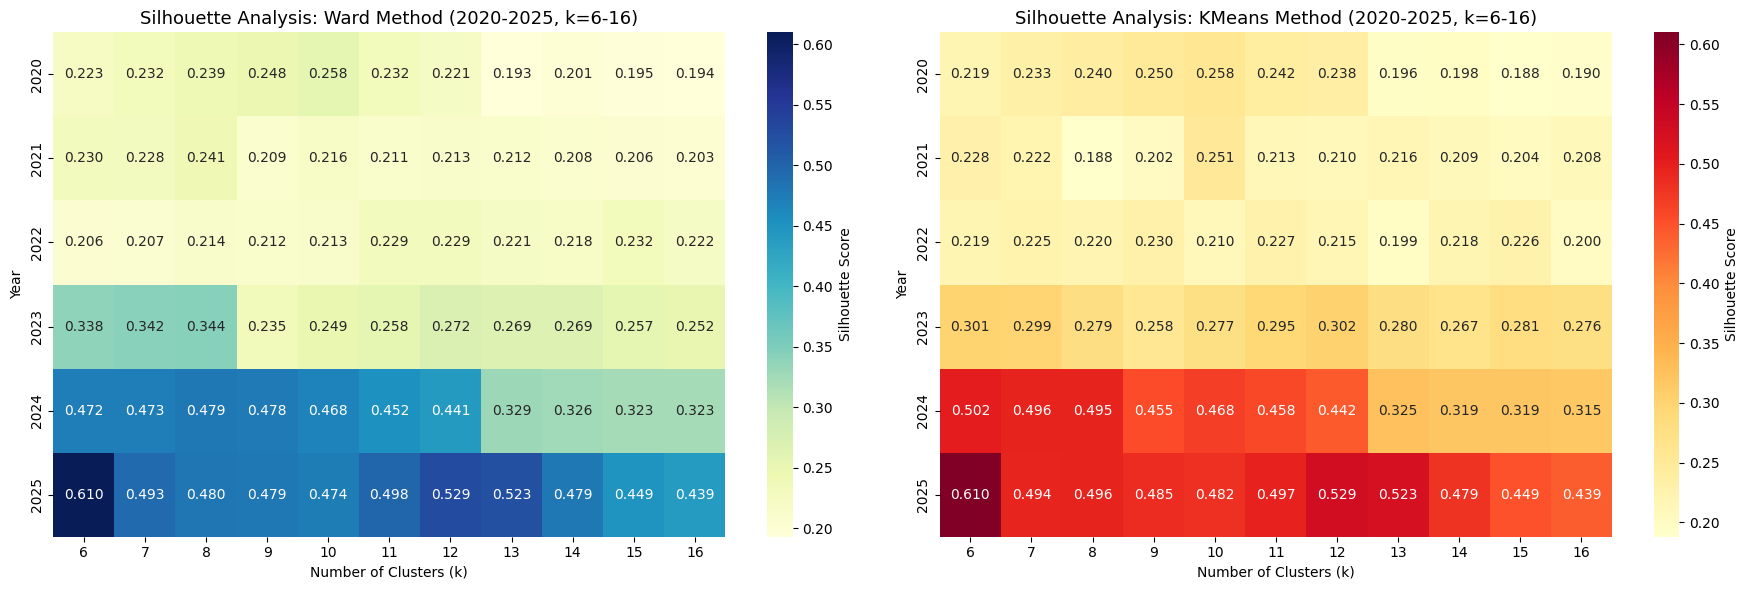

In [16]:
k_grid = range(6, 17)

records_ward = []
records_kmeans = []
for yr in YEARS:
    X = pivot.xs(yr, level="Year")
    X_std = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=0.9, random_state=RANDOM_STATE).fit_transform(X_std)
    for k in k_grid:
        lw = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_pca)
        records_ward.append({"Year": yr, "k": k, "Silhouette": silhouette_score(X_pca, lw)})
        lk = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50).fit_predict(X_pca)
        records_kmeans.append({"Year": yr, "k": k, "Silhouette": silhouette_score(X_pca, lk)})

df_ward = pd.DataFrame(records_ward).pivot(index="Year", columns="k", values="Silhouette").round(3)
df_kmeans = pd.DataFrame(records_kmeans).pivot(index="Year", columns="k", values="Silhouette").round(3)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(df_ward, annot=True, fmt=".3f", cmap="YlGnBu",
            cbar_kws={"label": "Silhouette Score"}, ax=axes[0])
axes[0].set_title("Silhouette Analysis: Ward Method (2020-2025, k=6-16)", fontsize=13)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Year")

sns.heatmap(df_kmeans, annot=True, fmt=".3f", cmap="YlOrRd",
            cbar_kws={"label": "Silhouette Score"}, ax=axes[1])
axes[1].set_title("Silhouette Analysis: KMeans Method (2020-2025, k=6-16)", fontsize=13)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Year")

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_8_Silhouette_Analysis_Ward_KMeans.png", dpi=600, bbox_inches="tight")
plt.show()

Silhouette values are low in 2020–2022, rise in 2023 (especially for Ward) and
peak in 2025 (0.610 at k = 6 for both methods).

### Figure 9 — Temporal evolution of country cluster memberships, 2020–2025

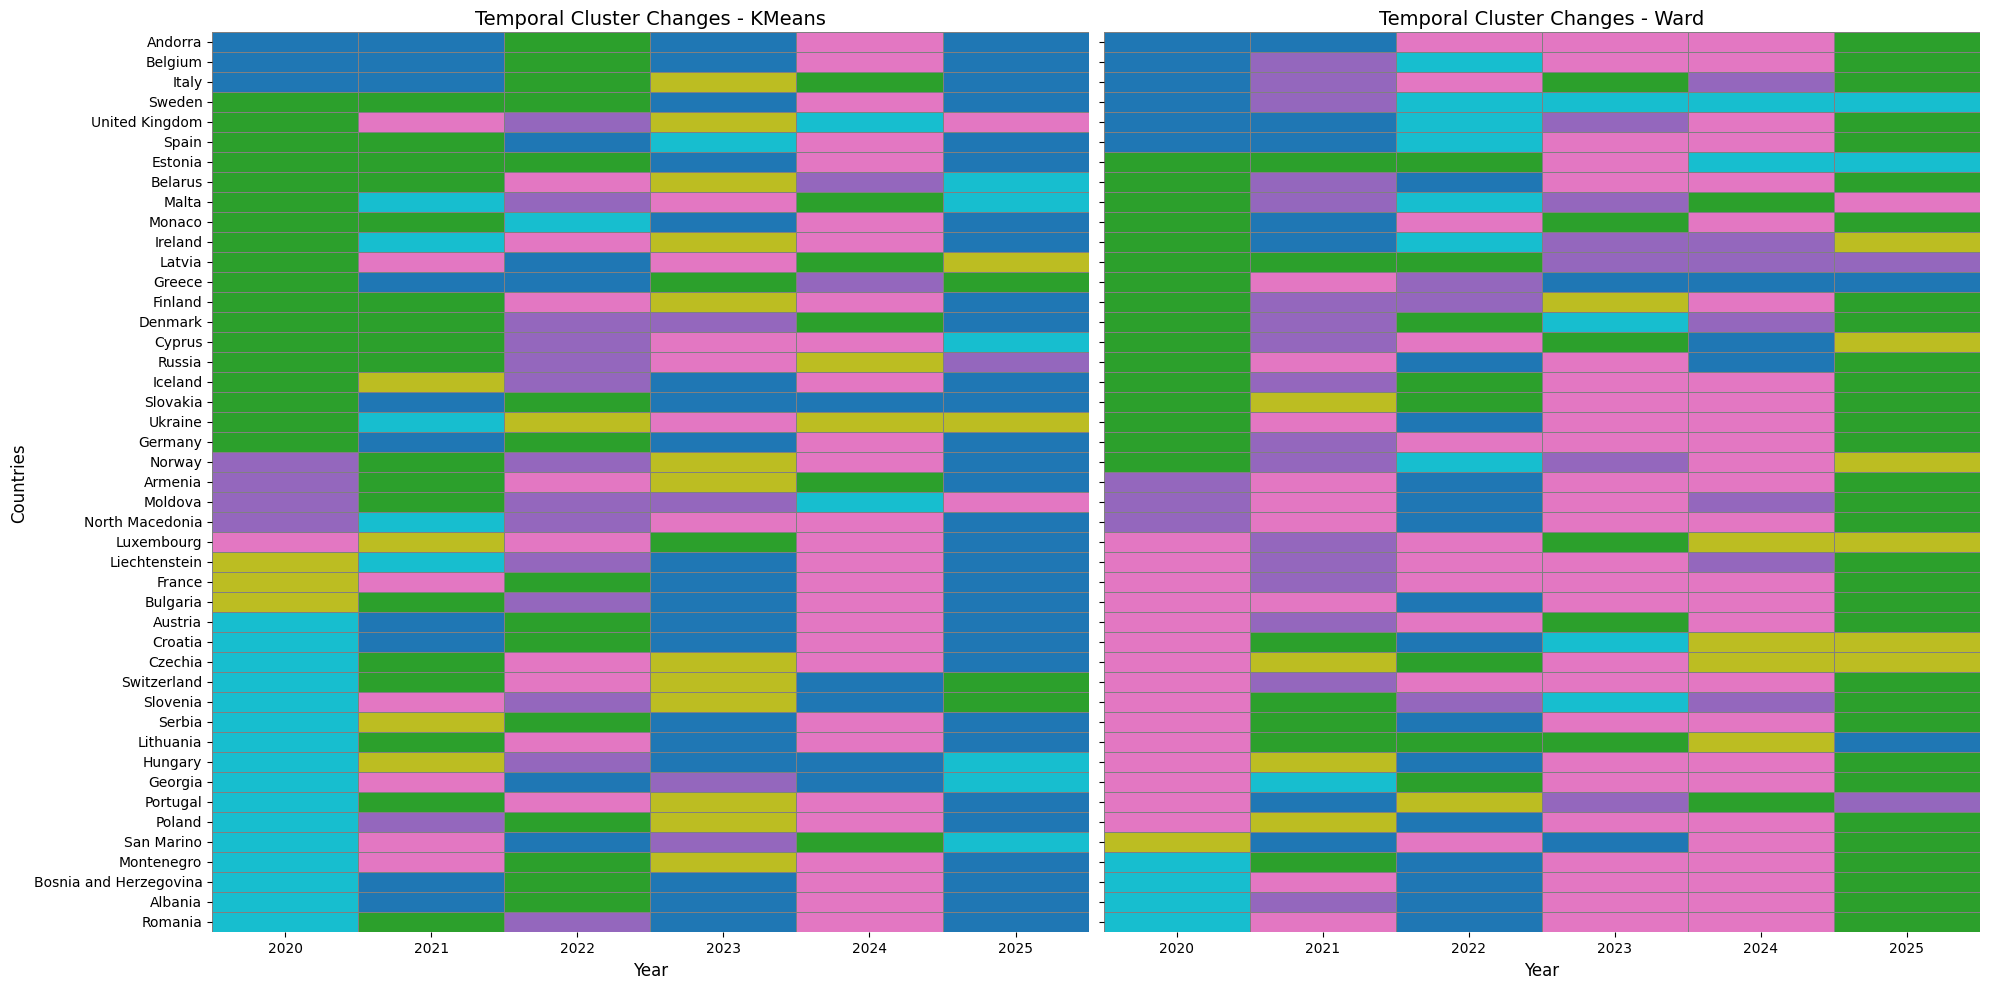

In [17]:
cluster_df_kmeans = pd.DataFrame(index=pivot.index.get_level_values(0).unique())
cluster_df_ward = pd.DataFrame(index=pivot.index.get_level_values(0).unique())

for year in YEARS:
    pivot_year = (pivot.reset_index()
                  .loc[lambda d: d["Year"] == year]
                  .set_index(["Country", "Year"]))
    X_year = StandardScaler().fit_transform(pivot_year.values)
    countries_year = pivot_year.index.get_level_values("Country")

    clusters_kmeans = KMeans(n_clusters=6, n_init=50, random_state=RANDOM_STATE).fit_predict(X_year)
    cluster_df_kmeans[year] = pd.Series(clusters_kmeans, index=countries_year)

    clusters_ward = AgglomerativeClustering(n_clusters=6, linkage="ward").fit_predict(X_year)
    cluster_df_ward[year] = pd.Series(clusters_ward, index=countries_year)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

sns.heatmap(cluster_df_kmeans.sort_values(by=2020), cmap="tab10", linewidths=0.5,
            linecolor="gray", cbar=False, ax=axes[0])
axes[0].set_title("Temporal Cluster Changes - KMeans", fontsize=14)
axes[0].set_ylabel("Countries", fontsize=12)
axes[0].set_xlabel("Year", fontsize=12)

sns.heatmap(cluster_df_ward.sort_values(by=2020), cmap="tab10", linewidths=0.5,
            linecolor="gray", cbar=False, ax=axes[1])
axes[1].set_title("Temporal Cluster Changes - Ward", fontsize=14)
axes[1].set_xlabel("Year", fontsize=12)
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_9.png", dpi=300, bbox_inches="tight")
plt.show()

Country groupings are reconfigured most strongly between 2021 and 2023; from 2023
onward assignments consolidate into fewer dominant clusters, with continued
stabilisation through 2025.